### Import Libraries and load Data

In [26]:
import pandas as pd
import numpy as np

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv("../Data/Raw_Dataset/emi_prediction_dataset.csv")

# Quick look
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_20352\75914518.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../Data/Raw_Dataset/emi_prediction_dataset.csv")


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


### Basic Dataset Info

In [27]:
# Shape
print("Shape:", df.shape)


Shape: (404800, 27)


In [28]:

# Data types & nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [29]:
# Summary statistics
df.describe(include='all')

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
count,404800.0,404800,404800,402396,404800,404800,404800.000000,404800,404800,402374.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800,404800.000000,402380.000000,402374,402449.000000,404800,4.048000e+05,404800.000000,404800,404800.000000
unique,41.0,8,2,4,13662,3,NaN,5,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,12261,NaN,5,NaN,NaN,3,NaN
top,38.0,Male,Married,Graduate,18000.0,Private,NaN,Large Indian,Rented,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,115800.0,NaN,Home Appliances EMI,NaN,NaN,Not_Eligible,NaN
freq,91577.0,237427,307837,181015,4159,283099,NaN,121139,161601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,243227,NaN,NaN,160,NaN,80988,NaN,NaN,312868,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,5.364079,NaN,NaN,5828.446490,2.940425,1.940425,4624.575593,4066.253706,5687.497777,12804.999506,7119.309783,NaN,4543.407609,700.856223,NaN,96769.051731,NaN,3.708554e+05,29.126677,NaN,6763.602156
std,NaN,NaN,NaN,NaN,NaN,NaN,6.079135,NaN,NaN,8648.604639,1.075199,1.075199,5061.074401,7319.344289,3392.671132,6993.853745,4510.447300,NaN,7034.901139,88.435548,NaN,81373.053976,NaN,3.451945e+05,18.100854,NaN,7741.263317
min,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,NaN,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,600.000000,1800.000000,600.000000,NaN,0.000000,0.000000,NaN,1400.000000,NaN,1.000000e+04,3.000000,NaN,500.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.200000,NaN,NaN,0.000000,2.000000,1.000000,0.000000,0.000000,3200.000000,7700.000000,3800.000000,NaN,0.000000,654.000000,NaN,38400.000000,NaN,1.240000e+05,15.000000,NaN,500.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,3.200000,NaN,NaN,0.000000,3.000000,2.000000,3000.000000,0.000000,4900.000000,11400.000000,6000.000000,NaN,0.000000,701.000000,NaN,74000.000000,NaN,2.360000e+05,25.000000,NaN,4211.200000
75%,NaN,NaN,NaN,NaN,NaN,NaN,7.200000,NaN,NaN,10600.000000,4.000000,3.000000,9000.000000,6500.000000,7400.000000,16400.000000,9300.000000,NaN,8000.000000,748.000000,NaN,130600.000000,NaN,4.940000e+05,40.000000,NaN,9792.000000


### Missing Value Check

In [30]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

bank_balance      2426
monthly_rent      2426
credit_score      2420
education         2404
emergency_fund    2351
dtype: int64

### Duplicate Check

In [31]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Target Variable Analysis

### A. Classification Target --> emi_eligibility

In [32]:
# Count distribution
df['emi_eligibility'].value_counts()

emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

In [33]:
# Percentage distribution
(df['emi_eligibility'].value_counts(normalize=True) * 100).round(2)

emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64

### B. Regression Target --> max_monthly_emi

In [34]:
df['max_monthly_emi'].describe()

count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64

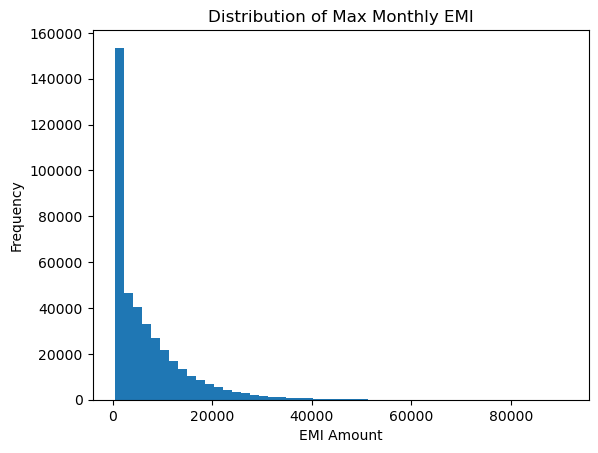

In [35]:
import matplotlib.pyplot as plt

plt.hist(df['max_monthly_emi'], bins=50)
plt.title("Distribution of Max Monthly EMI")
plt.xlabel("EMI Amount")
plt.ylabel("Frequency")
plt.show()

## Categorical vs Numerical Columns

In [36]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: ['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'bank_balance', 'emi_scenario', 'emi_eligibility']
Numerical Columns: ['years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']


## Class Imbalance Visualization

In [37]:
import seaborn as sns


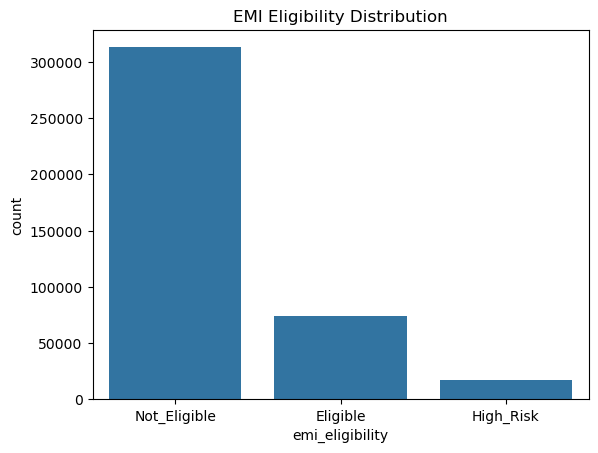

In [38]:
sns.countplot(x='emi_eligibility', data=df)
plt.title("EMI Eligibility Distribution")
plt.show()

## Correlation Analysis

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

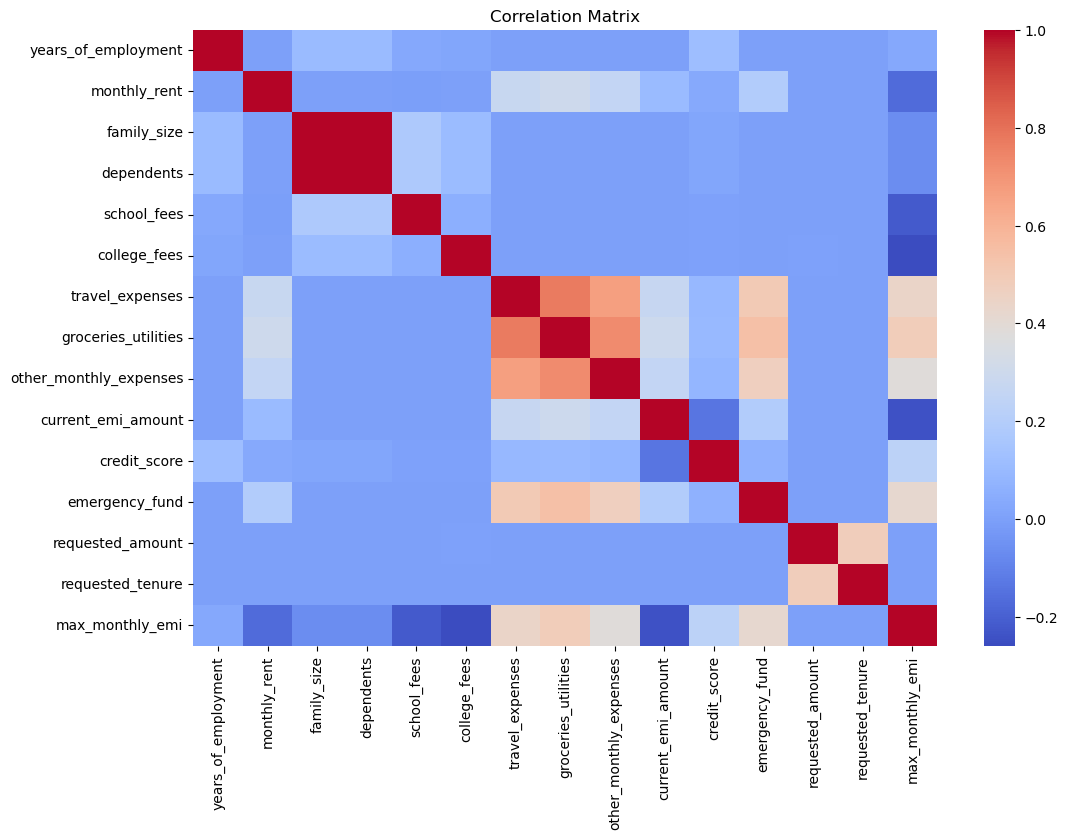

In [40]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [41]:
corr['max_monthly_emi'].sort_values(ascending=False)

max_monthly_emi           1.000000
groceries_utilities       0.484695
travel_expenses           0.440948
emergency_fund            0.415231
other_monthly_expenses    0.382055
credit_score              0.229441
years_of_employment       0.028887
requested_tenure          0.001006
requested_amount         -0.002034
dependents               -0.062266
family_size              -0.062266
monthly_rent             -0.170097
school_fees              -0.215234
current_emi_amount       -0.242434
college_fees             -0.258842
Name: max_monthly_emi, dtype: float64

## Feature vs Target

#### Salary vs EMI

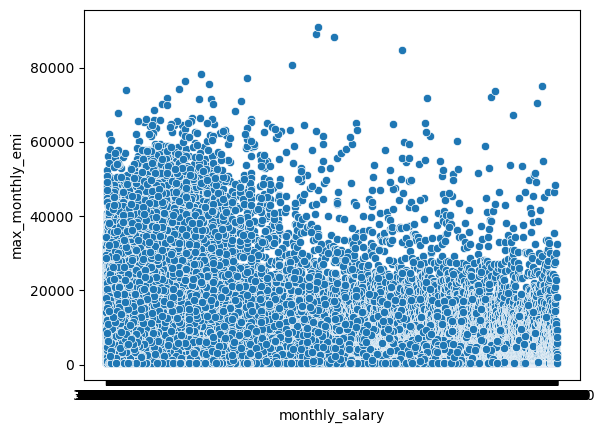

In [42]:
sns.scatterplot(x='monthly_salary', y='max_monthly_emi', data=df)
plt.show()

#### Credit Score vs Eligibility

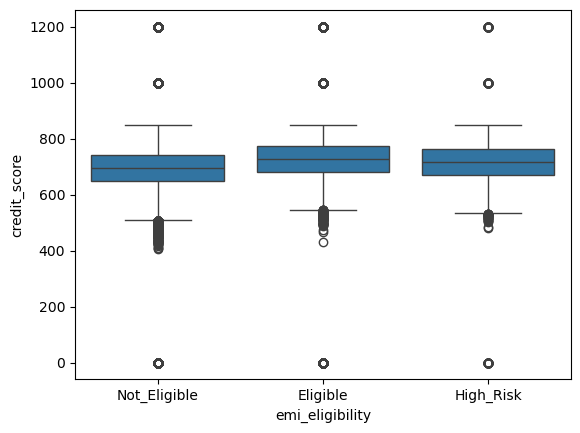

In [43]:
sns.boxplot(x='emi_eligibility', y='credit_score', data=df)
plt.show()

#### Existing EMI vs Eligibility

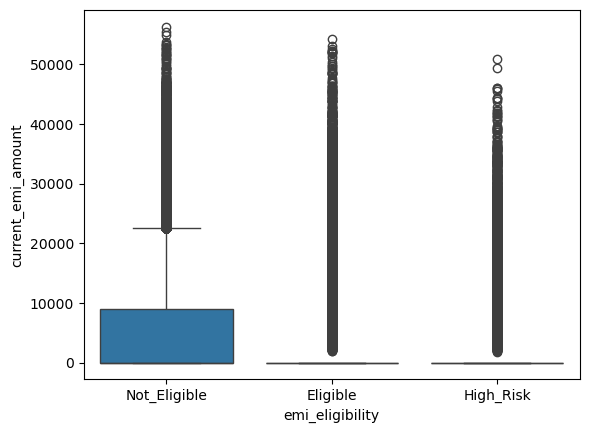

In [44]:
sns.boxplot(x='emi_eligibility', y='current_emi_amount', data=df)
plt.show()


## Class Imbalace Check

In [45]:
class_counts = df['emi_eligibility'].value_counts()

print(class_counts)

imbalance_ratio = class_counts.min() / class_counts.max()
print("Imbalance Ratio:", imbalance_ratio)


emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64
Imbalance Ratio: 0.05589577713284836


## EMI Scenario Distribution

In [46]:
df['emi_scenario'].value_counts()

emi_scenario
Home Appliances EMI        80988
Personal Loan EMI          80980
E-commerce Shopping EMI    80948
Education EMI              80942
Vehicle EMI                80942
Name: count, dtype: int64

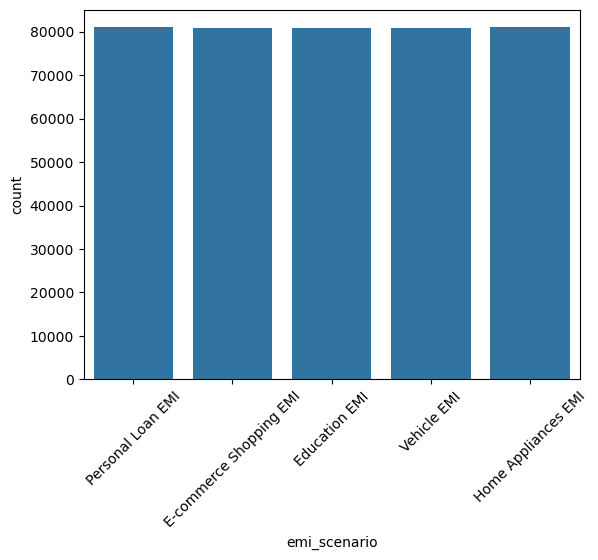

In [47]:
sns.countplot(x='emi_scenario', data=df)
plt.xticks(rotation=45)
plt.show()

## Key Observation 

#### Key Observations:

1. Dataset contains ~400K records with no/low missing values.
2. High imbalance observed in emi_eligibility:
   - High_Risk class is underrepresented.
3. Strong correlation observed between:
   - monthly_salary and max_monthly_emi
   - current_emi_amount and target
4. Possible data leakage suspected due to very high correlations.
5. Dataset appears structured and possibly rule-based.
"""